In [1]:
import nest_asyncio
nest_asyncio.apply()

In [2]:
import numpy as np # linear algebra
import pandas as pd# data processing, CSV file I/O (e.g. pd.read_csv)
from matplotlib import pyplot as plt

data = pd.read_csv('sign_language_data/sign_mnist_train.csv')

In [3]:
test_data = pd.read_csv('sign_language_data/sign_mnist_test.csv')

In [4]:
letters = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']

In [5]:
data_dev = np.array(test_data)
m_dev, n_dev = data_dev.shape
data_dev = data_dev.T
Y_dev = data_dev[0]
X_dev = data_dev[1:n_dev]
X_dev = X_dev / 255.

data_train = np.array(data)
m_train, n_train = data_train.shape
data_train = data_train.T
Y_train = data_train[0]
X_train = data_train[1:n_train]
X_train = X_train / 255.
_, m_train = X_train.shape

In [6]:
Y_train

array([ 3,  6,  2, ..., 18, 17, 23])

In [7]:
def init_params():
    W1 = np.random.rand(25, 784) - 0.5
    b1 = np.random.rand(25, 1) - 0.5
    W2 = np.random.rand(25, 25) - 0.5
    b2 = np.random.rand(25, 1) - 0.5
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A
    
def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def ReLU_deriv(Z):
    return Z > 0

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, 25))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m_train * dZ2.dot(A1.T)
    db2 = 1 / m_train * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m_train * dZ1.dot(X.T)
    db1 = 1 / m_train * np.sum(dZ1)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1    
    W2 = W2 - alpha * dW2  
    b2 = b2 - alpha * db2    
    return W1, b1, W2, b2

In [8]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [9]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.10, 1000)

Iteration:  0
[4 4 4 ... 4 8 4] [ 3  6  2 ... 18 17 23]
0.039701329448187946
Iteration:  10
[13 13 13 ... 13 13 13] [ 3  6  2 ... 18 17 23]
0.03820797668912766
Iteration:  20
[13 13 13 ... 13 13 13] [ 3  6  2 ... 18 17 23]
0.03944636678200692
Iteration:  30
[13 13 13 ... 13 13 13] [ 3  6  2 ... 18 17 23]
0.04086687306501548
Iteration:  40
[13 13 13 ... 13 13 13] [ 3  6  2 ... 18 17 23]
0.041231105445274085
Iteration:  50
[13 13 13 ... 13 13 13] [ 3  6  2 ... 18 17 23]
0.04257876525223092
Iteration:  60
[13 13  0 ... 13 13 13] [ 3  6  2 ... 18 17 23]
0.04658532143507558
Iteration:  70
[13 13  0 ... 13 13 13] [ 3  6  2 ... 18 17 23]
0.04913494809688582
Iteration:  80
[17 13  0 ... 13 13 13] [ 3  6  2 ... 18 17 23]
0.05434347113458386
Iteration:  90
[17 13 11 ...  0 13 13] [ 3  6  2 ... 18 17 23]
0.06089965397923876
Iteration:  100
[17 13 11 ...  0 13 13] [ 3  6  2 ... 18 17 23]
0.06567109816062648
Iteration:  110
[17 13 11 ...  0 17 13] [ 3  6  2 ... 18 17 23]
0.07656164633035877
Iterati

KeyboardInterrupt: 

In [ ]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", letters[prediction[0]])
    print("Label: ", letters[label])
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  Y
Label:  D


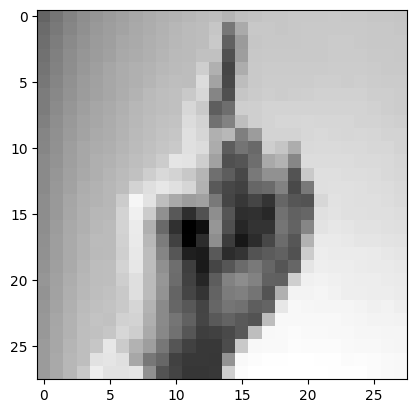

Prediction:  M
Label:  G


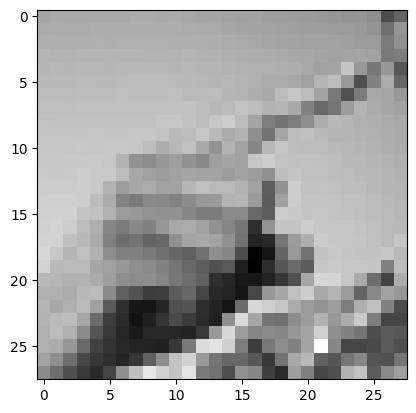

Prediction:  C
Label:  C


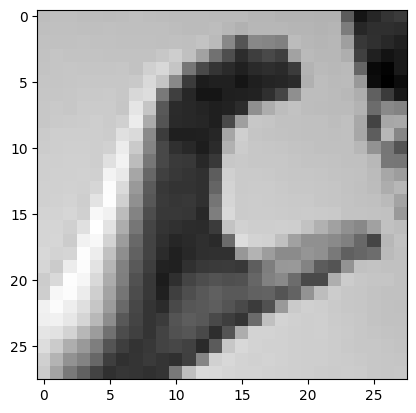

Prediction:  C
Label:  C


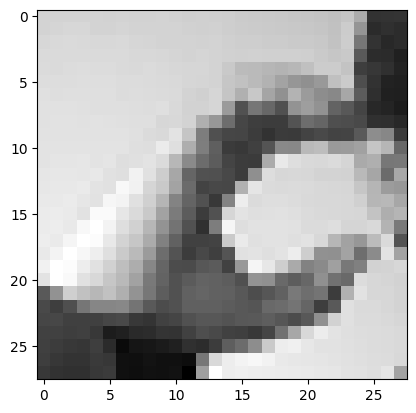

Prediction:  A
Label:  O


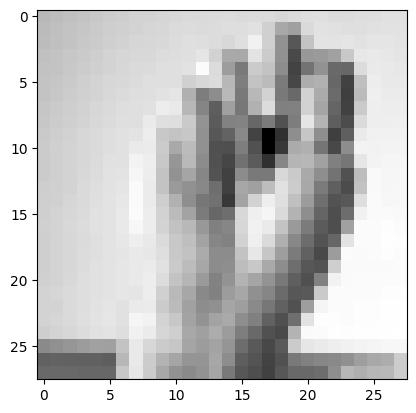

Prediction:  R
Label:  R


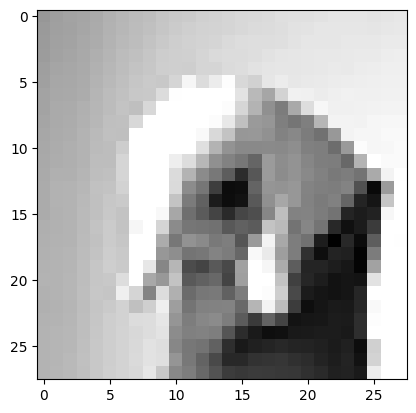

Prediction:  W
Label:  I


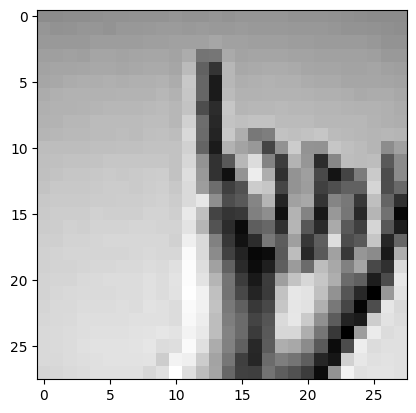

Prediction:  F
Label:  X


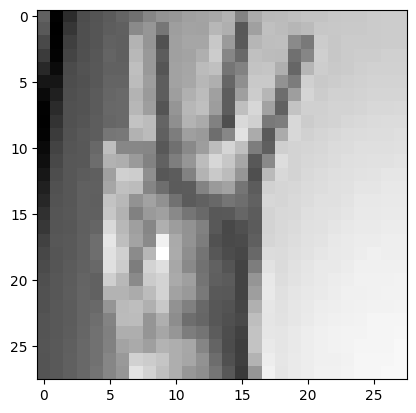

Prediction:  I
Label:  D


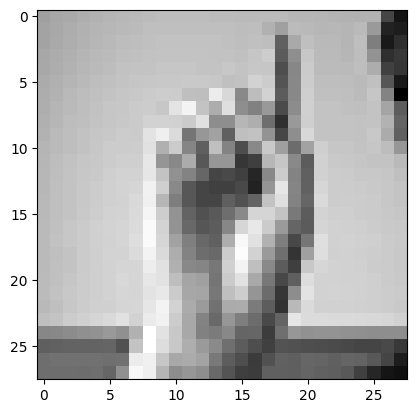

Prediction:  I
Label:  D


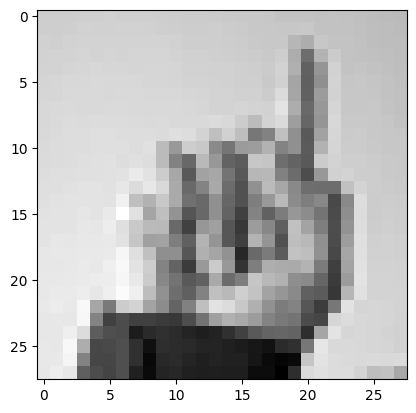

In [ ]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)
test_prediction(4, W1, b1, W2, b2)
test_prediction(5, W1, b1, W2, b2)
test_prediction(6, W1, b1, W2, b2)
test_prediction(7, W1, b1, W2, b2)
test_prediction(8, W1, b1, W2, b2)
test_prediction(9, W1, b1, W2, b2)

In [ ]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_dev)

[ 6  5 17 ...  2  0  2] [ 6  5 10 ...  2  4  2]


np.float64(0.4199665365309537)